# Задание 5

In [13]:
# Подключим нужные для базовых операций библиотеки
import seaborn as sb
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Подключим пакеты для использования OLS метода и тестов
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# Подгрузим полезные функции
from my_utils import *

# Сделаем автоподгрузку всех изменений при перепрогонке ячейки
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Гененеруем датасет
Определим параметры под датасет

In [16]:
# Определим параметры выборки для задачи преобразования факторов
# Создадим удобный словарь, чтобы передавать его в функцию
dist_params = dict(

    # Зададим параметры распределения факторов
    x1_mean = 10,
    x1_std = 5,
    x2_mean = 20,
    x2_std = 5,
    
    # Зададим параметры распределения ошибки
    e_mean = 0,
    e_std = 10,

    corr_12 = -0.7,

    # Укажем размер выборки
    N = 1000,

    # Зададим действительные параметры модели
    beta0 = 20,
    beta1 = 7,
    beta2 = 3
)

# Установим стартовую точку для алгоритма генерации случайных чисел
RANDOM_SEED = 42

In [ ]:
dt_data = gen_data(y_type='multivariate', params=dist_params, seed=RANDOM_SEED)

display(dt_data)

,x1,x2,e,y
0,7.442513,22.021991,-6.751783,131.411784
1,9.963638,25.935031,-1.445187,166.105373
2,10.625989,18.467202,-7.924199,141.859333
3,4.206320,28.765942,-3.079615,132.662449
4,13.214833,18.886493,-18.936147,150.227163
...,...,...,...,...
995,7.770973,25.150384,0.774805,150.622772
996,5.891005,26.852244,2.577525,144.371291
997,10.452241,23.692433,-12.417606,151.825380
998,8.414514,18.170000,3.341764,136.753363


# Построение модели и вывод результатов

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     3645.
Date:                Fri, 21 Feb 2025   Prob (F-statistic):               0.00
Time:                        21:20:52   Log-Likelihood:                -3700.4
No. Observations:                 999   AIC:                             7407.
Df Residuals:                     996   BIC:                             7422.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.0645      2.441      7.809      0.0

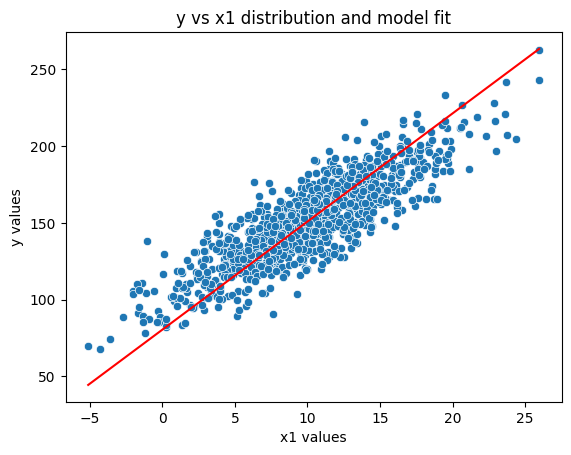

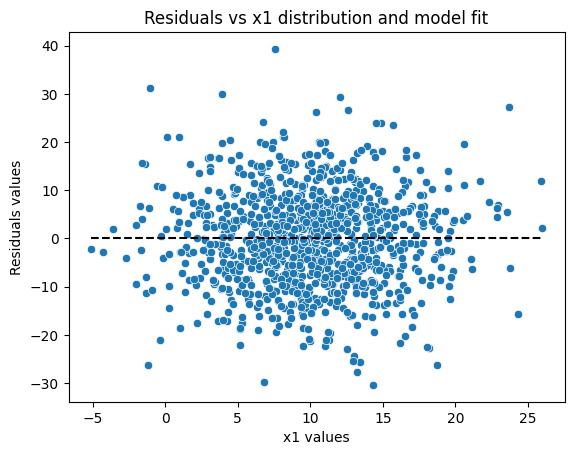

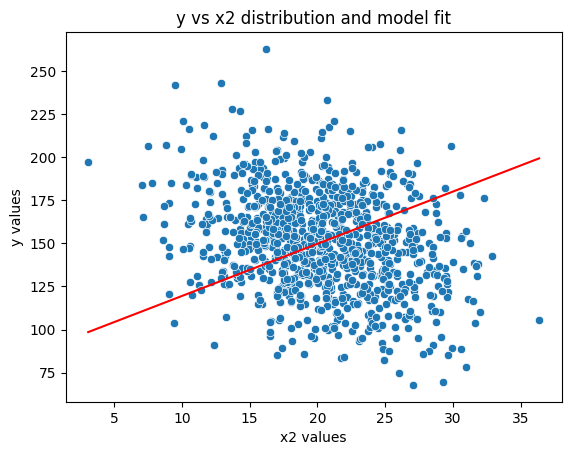

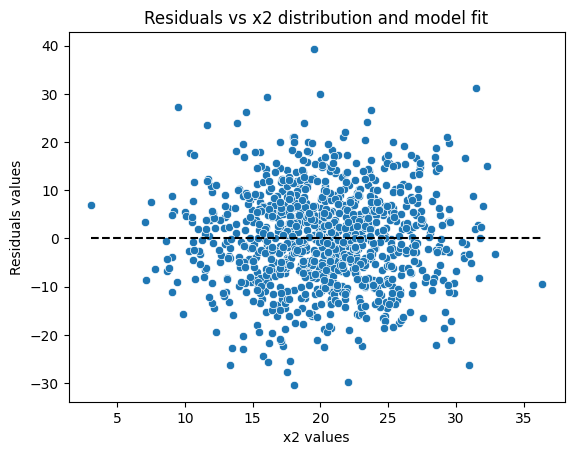

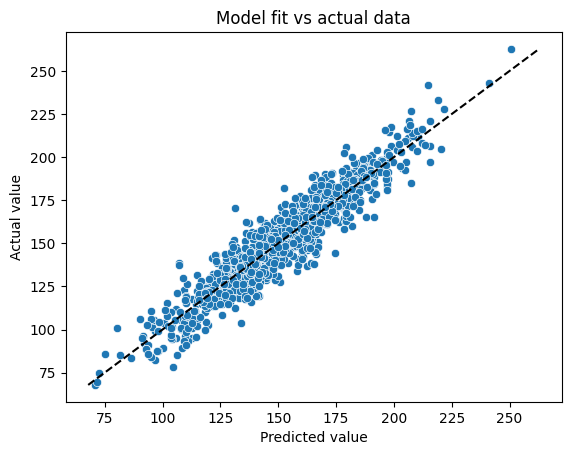

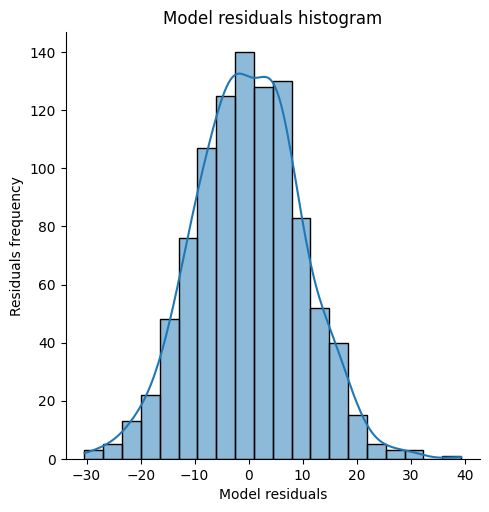

,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.727102,True,0.998757,,,gaussian distribution
1,Epps-Pulley test,0.95,0.05,0.921865,True,0.021493,0.377799,True,gaussian distribution
2,D'Agostino's K-squared test,0.95,0.05,0.359536,True,2.045881,,,gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,0.201954,0.784,True,gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.985637,True,0.014246,,,gaussian distribution
5,Lilliefors test,0.95,0.05,0.930361,True,0.014367,,,gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.973217,True,0.030888,,,gaussian distribution
7,Chi-squared test,0.95,0.05,0.0,False,280912308232211333120.0,,,not gaussian distribution
8,Jarque–Bera test,0.95,0.05,-,-,-,,,count less than 2000
9,skewtest,0.95,0.05,0.415955,True,0.813459,,,gaussian distribution


In [32]:
# Обучим модель и выведем результаты
dt_data, model_data = train_model(dt_data, target='y', feature_names=['x1', 'x2'], show_results=True, return_norm_tests=True)

**Выводы результатов:**

Итоговый вид модели выглядить так:

$y = 18.41 + 7.01x_1 + 3.01x_2$ 

$R^2 = 0.88$ и статистика Фишера большая => можно сделать вывод модель адекватна.

Подозрений, что какой-то коэффициент не значим, нет, так как $p-value < 0.05$.

Все тесты на нормальность остатков пройдены. 


### Тесты на разные размеры выборок

Теперь посмотрим какие будут доверительные интервалы оценок $\beta_1,\beta_2$ датасетах разных размеров. Например размерах от 30 до 1000. 

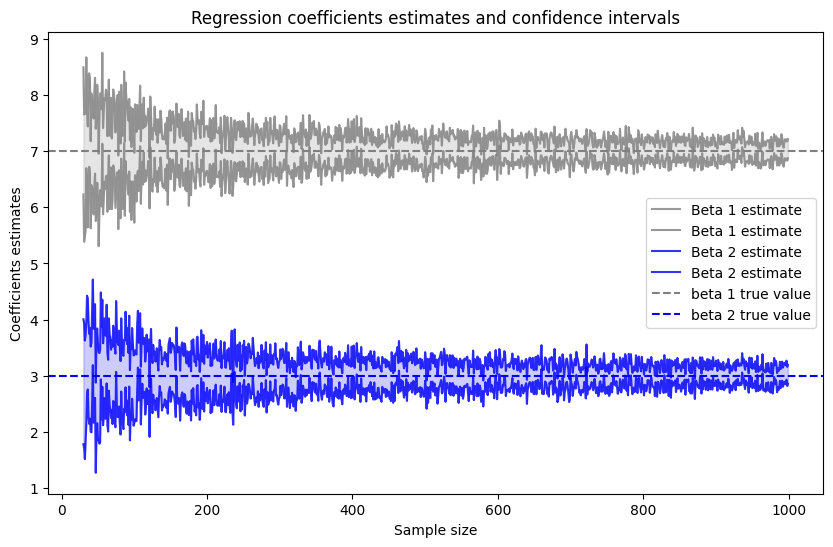

In [33]:
beta1 = []
beta2 = []
beta_1_lower = []
beta_1_upper = []
beta_2_lower = []
beta_2_upper = []
sample_sizes = range(30, 1000)
for N in range(30, 1000):
    dist_params['N'] = N
    dt_data = gen_data(y_type='multivariate', params=dist_params, seed=RANDOM_SEED)
    dt_data, model = train_model(dt_data, target='y', feature_names=['x1', 'x2'])
    coef_interval = model.conf_int()

    beta1.append(coef_interval.loc['x1'])
    beta2.append(coef_interval.loc['x2'])
    beta_1_lower.append(coef_interval.iloc[1, 0])
    beta_1_upper.append(coef_interval.iloc[1, 1])
    beta_2_lower.append(coef_interval.iloc[2, 0])
    beta_2_upper.append(coef_interval.iloc[2, 1])

beta_1 = np.array(beta1)
beta_2 = np.array(beta2)

beta_1_lower = np.array(beta_1_lower)
beta_1_upper = np.array(beta_1_upper)
beta_2_lower = np.array(beta_2_lower)
beta_2_upper = np.array(beta_2_upper)

# Визуализация
plt.figure(figsize=(10, 6))

plt.fill_between(sample_sizes, beta_1_lower, beta_1_upper, color='gray', alpha=0.2)
plt.fill_between(sample_sizes, beta_2_lower, beta_2_upper, color='blue', alpha=0.2)

plt.plot(sample_sizes, beta_1, color='gray', alpha=0.8, label='Beta 1 estimate')
plt.plot(sample_sizes, beta_2, color='blue', alpha=0.8, label='Beta 2 estimate')

# Добавляем истинные значения
plt.axhline(y=dist_params['beta1'], color='gray', linestyle='dashed', label='beta 1 true value')
plt.axhline(y=dist_params['beta2'], color='blue', linestyle='dashed', label='beta 2 true value')

# Настройка осей
plt.xlabel('Sample size')
plt.ylabel('Coefficients estimates')
plt.title('Regression coefficients estimates and confidence intervals')
plt.legend()
plt.show()
    

**Вывод:** Доверительные интервалы уменьшаются с увеличением размера датасета. Как мы видим из графика, реальные значения могут выходить из доверительных интервалов, даже при больших значениях.